In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

from sklift.models import TwoModels
from sklift.metrics import uplift_auc_score

In [4]:
df = pd.read_csv("../Dataset/hillstrom.csv")

df['treatment'] = df['segment'].apply(lambda x: 0 if x == 'No E-Mail' else 1)

In [6]:
features = [
    'recency',
    'history',
    'mens',
    'womens',
    'zip_code',
    'newbie',
    'channel'
]

X = df[features]
y = df['conversion']
treatment = df['treatment']

In [ ]:
le = LabelEncoder()

X['zip_code'] = le.fit_transform(X['zip_code'])
X['channel'] = le.fit_transform(X['channel'])

C:\Users\mahes\AppData\Local\Temp\ipykernel_62324\4108387735.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['zip_code'] = le.fit_transform(X['zip_code'])
C:\Users\mahes\AppData\Local\Temp\ipykernel_62324\4108387735.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['channel'] = le.fit_transform(X['channel'])


In [8]:
X_train, X_test, y_train, y_test, tr_train, tr_test = train_test_split(
    X, y, treatment,
    test_size=0.3,
    random_state=42
)

In [10]:
from sklift.models import TwoModels
from sklearn.ensemble import RandomForestClassifier

uplift_model = TwoModels(
    estimator_trmnt=RandomForestClassifier(n_estimators=100),
    estimator_ctrl=RandomForestClassifier(n_estimators=100)
)

In [11]:
uplift_model.fit(
    X_train,
    y_train,
    tr_train
)

TwoModels(estimator_ctrl=RandomForestClassifier(),
          estimator_trmnt=RandomForestClassifier())

In [12]:
uplift_predictions = uplift_model.predict(X_test)

uplift_predictions[:10]

array([0.  , 0.03, 0.  , 0.  , 0.  , 0.01, 0.  , 0.  , 0.  , 0.01])

In [13]:
from sklift.metrics import uplift_auc_score

score = uplift_auc_score(y_test, uplift_predictions, tr_test)

print("Uplift AUC Score:", score)

Uplift AUC Score: -0.002311396192064186


In [14]:
results = X_test.copy()

results['uplift_score'] = uplift_predictions

results.sort_values(by='uplift_score', ascending=False).head(10)

,recency,history,mens,womens,zip_code,newbie,channel,uplift_score
10827,1,564.04,0,1,1,1,0,0.73
4399,1,62.16,0,1,0,0,2,0.66
26481,1,75.67,0,1,0,0,2,0.64
12944,6,176.79,1,0,1,0,1,0.63
45878,2,996.89,1,1,2,1,2,0.63
34004,9,83.98,0,1,0,0,2,0.63
6467,9,297.72,0,1,1,1,1,0.61
7128,1,136.98,1,0,0,1,1,0.61
63940,3,315.79,1,0,0,1,1,0.61
48556,4,275.04,1,0,1,1,2,0.60


The uplift model identifies customers who are most likely to respond to marketing emails.

By targeting only the top uplift customers, companies can reduce marketing costs while maintaining high conversion rates.

UPLIFT EVALUATION

In [15]:
from sklift.metrics import uplift_curve
from sklift.metrics import qini_curve

import matplotlib.pyplot as plt

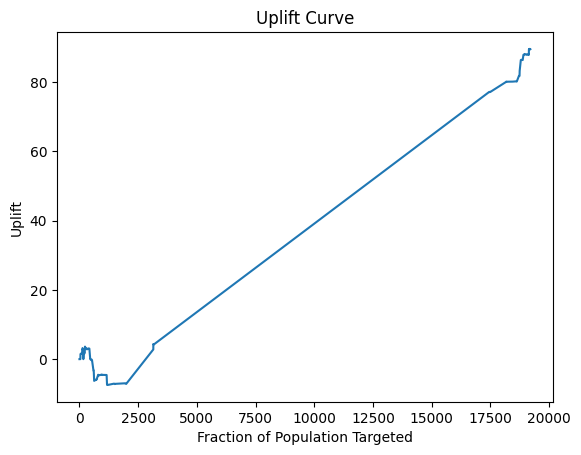

In [16]:
x, y = uplift_curve(y_test, uplift_predictions, tr_test)

plt.figure()

plt.plot(x, y)

plt.title("Uplift Curve")
plt.xlabel("Fraction of Population Targeted")
plt.ylabel("Uplift")

plt.show()

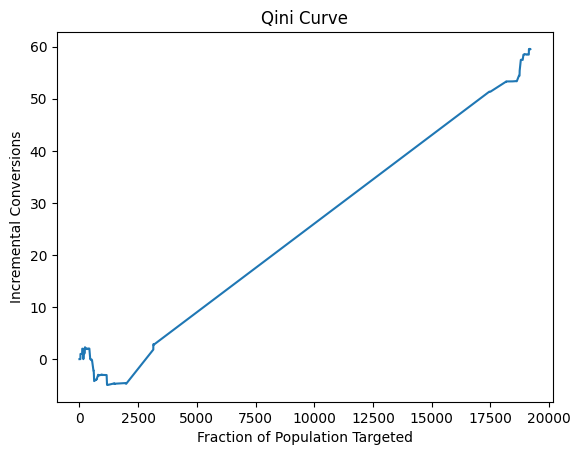

In [17]:
x_qini, y_qini = qini_curve(y_test, uplift_predictions, tr_test)

plt.figure()

plt.plot(x_qini, y_qini)

plt.title("Qini Curve")
plt.xlabel("Fraction of Population Targeted")
plt.ylabel("Incremental Conversions")

plt.show()

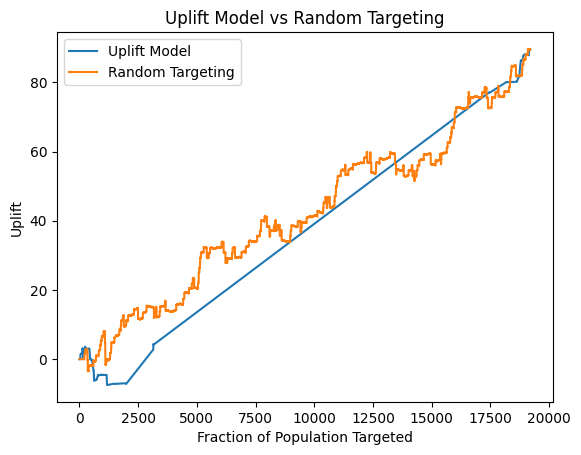

In [18]:
import numpy as np

random_predictions = np.random.rand(len(y_test))

x_rand, y_rand = uplift_curve(y_test, random_predictions, tr_test)

plt.figure()

plt.plot(x, y, label="Uplift Model")
plt.plot(x_rand, y_rand, label="Random Targeting")

plt.title("Uplift Model vs Random Targeting")
plt.xlabel("Fraction of Population Targeted")
plt.ylabel("Uplift")

plt.legend()

plt.show()

In [19]:
results = X_test.copy()

results['uplift_score'] = uplift_predictions

top_customers = results.sort_values(by='uplift_score', ascending=False)

top_customers.head(10)

,recency,history,mens,womens,zip_code,newbie,channel,uplift_score
10827,1,564.04,0,1,1,1,0,0.73
4399,1,62.16,0,1,0,0,2,0.66
26481,1,75.67,0,1,0,0,2,0.64
12944,6,176.79,1,0,1,0,1,0.63
45878,2,996.89,1,1,2,1,2,0.63
34004,9,83.98,0,1,0,0,2,0.63
6467,9,297.72,0,1,1,1,1,0.61
7128,1,136.98,1,0,0,1,1,0.61
63940,3,315.79,1,0,0,1,1,0.61
48556,4,275.04,1,0,1,1,2,0.60


In [20]:
top_30_percent = int(len(top_customers) * 0.3)

target_customers = top_customers.head(top_30_percent)

target_customers

,recency,history,mens,womens,zip_code,newbie,channel,uplift_score
10827,1,564.04,0,1,1,1,0,0.73
4399,1,62.16,0,1,0,0,2,0.66
26481,1,75.67,0,1,0,0,2,0.64
12944,6,176.79,1,0,1,0,1,0.63
45878,2,996.89,1,1,2,1,2,0.63
...,...,...,...,...,...,...,...,...
34362,2,39.13,1,0,1,1,2,0.00
45029,10,243.04,0,1,2,0,2,0.00
37933,6,137.93,0,1,1,1,1,0.00
20315,2,69.97,0,1,2,0,2,0.00


This project analyzed the effectiveness of marketing emails using
A/B testing and uplift modeling.

The statistical analysis confirmed that email campaigns significantly
increase customer conversions.

The uplift model identified customers most likely to respond to emails,
allowing businesses to target only high-impact users and reduce
marketing costs.